## Problem Formulation: Max-Cut
The Max-Cut problem asks: Given a network of connected nodes, how can we split the nodes into two distinct groups (Group 0 and Group 1) such that we sever/cut the MAXIMUM number of edges between them?

Mathematical Mapping to QUBO:For every edge $(u, v)$, the cut cost is:$$E(x_u, x_v) = 2x_u x_v - x_u - x_v$$

If $x_u = 0$ and $x_v = 1$: Energy is $-1$ (Good! Edge is Cut)

If $x_u = 1$ and $x_v = 0$: Energy is $-1$ (Good! Edge is Cut)

If $x_u = 0$ and $x_v = 0$: Energy is $0$ (No Cut)

If $x_u = 1$ and $x_v = 1$: Energy is $0$ (No Cut)

In [1]:
!pip install dwave-neal networkx matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 92.9 MB/s eta 0:00:00


In [2]:
# Install prerequisites if needed
# !pip install dwave-neal networkx matplotlib numpy

import networkx as nx
import matplotlib.pyplot as plt
import neal  # D-Wave's Simulated Annealing Sampler (Runs locally)
import numpy as np

print("All libraries imported successfully!")

All libraries imported successfully!


### Creating a Target Graph
Let's create a 6-node network graph representing 6 servers that need to be divided across two data centers to maximize cross-data-center communication links.

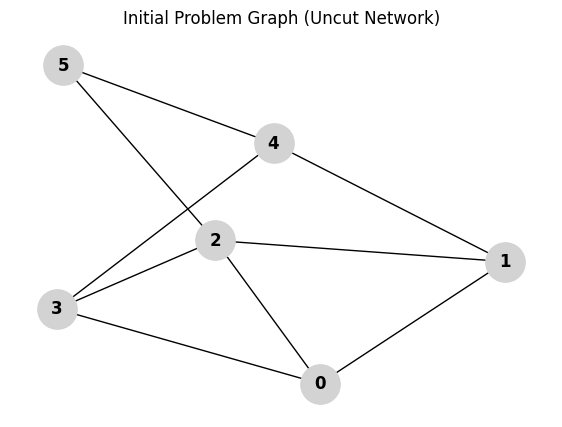

In [3]:
# Create an undirected graph
G = nx.Graph()

# Add edges between nodes (0 to 5)
edges = [
    (0, 1), (0, 2), (0, 3),
    (1, 2), (1, 4),
    (2, 3), (2, 5),
    (3, 4), (4, 5)
]
G.add_edges_from(edges)

# Plot initial graph layout
pos = nx.spring_layout(G, seed=42) # Consistent layout
plt.figure(figsize=(7, 5))
nx.draw_networkx(G, pos, node_color='lightgray', node_size=800, font_weight='bold', edge_color='black')
plt.title("Initial Problem Graph (Uncut Network)")
plt.axis('off')
plt.show()

### Building the QUBO Matrix ($Q$)
We now iterate through every edge in our graph and apply our mathematical formula to populate the dictionary Q representing the matrix.

In [4]:
# Initialize empty QUBO dictionary
Q = {}

# Populate QUBO according to the Max-Cut cost function: 2*x_u*x_v - x_u - x_v
for u, v in G.edges():
    # Linear terms (Diagonals of Q matrix)
    Q[(u, u)] = Q.get((u, u), 0) - 1
    Q[(v, v)] = Q.get((v, v), 0) - 1

    # Quadratic interaction term (Off-Diagonals of Q matrix)
    # Ensures symmetry by enforcing tuple ordering (u, v) where u < v
    edge_key = (u, v) if u < v else (v, u)
    Q[edge_key] = Q.get(edge_key, 0) + 2

print("Generated QUBO Matrix (Sparse Dictionary representation):")
for key, value in Q.items():
    print(f"  {key} : {value}")

Generated QUBO Matrix (Sparse Dictionary representation):
  (0, 0) : -3
  (1, 1) : -3
  (0, 1) : 2
  (2, 2) : -4
  (0, 2) : 2
  (3, 3) : -3
  (0, 3) : 2
  (1, 2) : 2
  (4, 4) : -3
  (1, 4) : 2
  (2, 3) : 2
  (5, 5) : -2
  (2, 5) : 2
  (3, 4) : 2
  (4, 5) : 2


### Running the D-Wave Annealing Sampler
We pass our Q dictionary directly into neal.SimulatedAnnealingSampler().

Note: To switch from this local simulator to a physical D-Wave Quantum Processing Unit (QPU), you simply replace neal.SimulatedAnnealingSampler() with EmbeddingComposite(DWaveSampler()) from dwave.system.

In [5]:
# Instantiate the D-Wave Annealer Sampler
sampler = neal.SimulatedAnnealingSampler()

# Run the annealer for 100 reads (100 sample runs)
response = sampler.sample_qubo(Q, num_reads=100)

# Extract the ground state (lowest energy solution)
best_sample = response.first.sample
best_energy = response.first.energy

print(f"Best Solution Found: {best_sample}")
print(f"Minimum Energy (Ground State): {best_energy}")

Best Solution Found: {0: np.int8(1), 1: np.int8(0), 2: np.int8(1), 3: np.int8(0), 4: np.int8(1), 5: np.int8(0)}
Minimum Energy (Ground State): -8.0


To make the result immediately clear for anyone:

Red Nodes represent Group 0 ($x_i = 0$).

Blue Nodes represent Group 1 ($x_i = 1$).

Green Dashed Lines represent Cut Edges (successful connections between Group 0 & Group 1).

Gray Solid Lines represent Uncut Internal Edges (connections inside the same group).

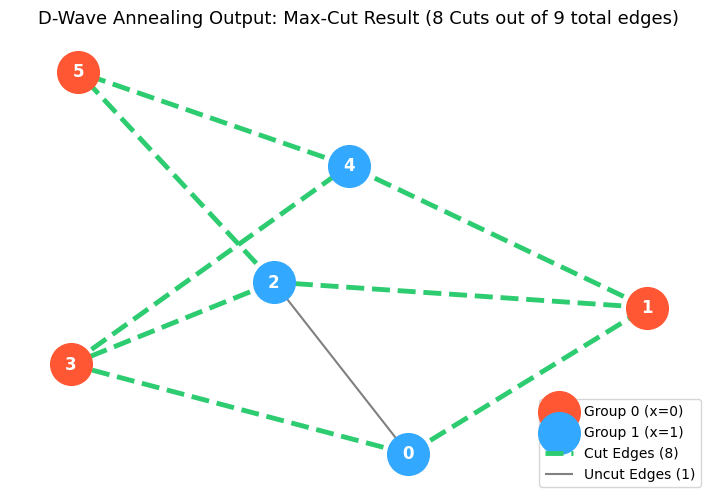


--- SUMMARY REPORT ---
Total Edges in Graph: 9
Successfully Cut Edges: 8
Max-Cut Efficiency: 88.9%


In [6]:
# Group nodes based on annealing response
group_0 = [node for node, val in best_sample.items() if val == 0]
group_1 = [node for node, val in best_sample.items() if val == 1]

# Categorize edges into CUT (Cross-group) and UNCUT (Internal)
cut_edges = []
uncut_edges = []

for u, v in G.edges():
    if best_sample[u] != best_sample[v]:
        cut_edges.append((u, v))
    else:
        uncut_edges.append((u, v))

# Plotting the Final Solution
plt.figure(figsize=(9, 6))

# Draw Group 0 Nodes (Red)
nx.draw_networkx_nodes(G, pos, nodelist=group_0, node_color='#FF5733', node_size=900, label='Group 0 (x=0)')

# Draw Group 1 Nodes (Blue)
nx.draw_networkx_nodes(G, pos, nodelist=group_1, node_color='#33A8FF', node_size=900, label='Group 1 (x=1)')

# Draw Node Labels
nx.draw_networkx_labels(G, pos, font_color='white', font_weight='bold')

# Draw Cut Edges (Green, Dashed, Thick)
nx.draw_networkx_edges(G, pos, edgelist=cut_edges, edge_color='#2ECC71', width=3.5, style='dashed', label=f'Cut Edges ({len(cut_edges)})')

# Draw Uncut Edges (Gray, Solid, Thin)
nx.draw_networkx_edges(G, pos, edgelist=uncut_edges, edge_color='gray', width=1.5, style='solid', label=f'Uncut Edges ({len(uncut_edges)})')

plt.title(f"D-Wave Annealing Output: Max-Cut Result ({len(cut_edges)} Cuts out of {len(G.edges())} total edges)", fontsize=13)
plt.legend(loc='lower right', frameon=True)
plt.axis('off')
plt.show()

print(f"\n--- SUMMARY REPORT ---")
print(f"Total Edges in Graph: {len(G.edges())}")
print(f"Successfully Cut Edges: {len(cut_edges)}")
print(f"Max-Cut Efficiency: {(len(cut_edges)/len(G.edges()))*100:.1f}%")

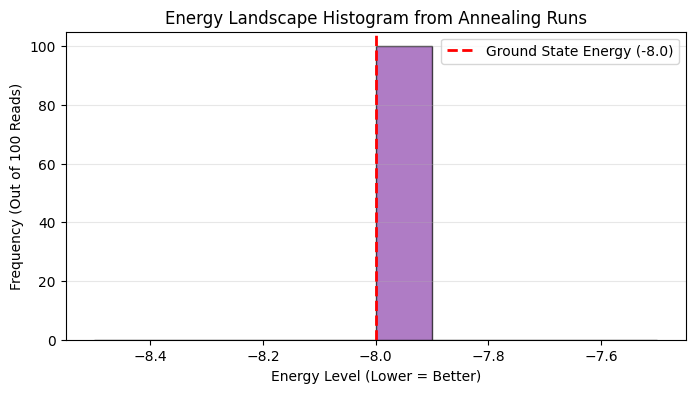

In [7]:
# Extract all energy levels from the 100 reads
energies = [record.energy for record in response.data()]

plt.figure(figsize=(8, 4))
plt.hist(energies, bins=10, color='#8E44AD', edgecolor='black', alpha=0.7)
plt.axvline(best_energy, color='red', linestyle='dashed', linewidth=2, label=f'Ground State Energy ({best_energy})')

plt.xlabel("Energy Level (Lower = Better)")
plt.ylabel("Frequency (Out of 100 Reads)")
plt.title("Energy Landscape Histogram from Annealing Runs")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()